# Import libraries 

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## Data Exploration:

Data Dictionary (column description)
- Gender: Gender of the student (male/female)
- EthnicGroup: Ethnic group of the student (group A to E)
- ParentEduc: Parent(s) education background (from some_highschool to master's degree)
- LunchType: School lunch type (standard or free/reduced)
- TestPrep: Test preparation course followed (completed or none)
- ParentMaritalStatus: Parent(s) marital status (married/single/widowed/divorced)
- PracticeSport: How often the student parctice sport (never/sometimes/regularly))
- IsFirstChild: If the child is first child in the family or not (yes/no)
- NrSiblings: Number of siblings the student has (0 to 7)
- TransportMeans: Means of transport to school (schoolbus/private)
- WklyStudyHours: Weekly self-study hours(less that 5hrs; between 5 and 10hrs; more than 10hrs)
- MathScore: math test score(0-100)
- ReadingScore: reading test score(0-100)
- WritingScore: writing test score(0-100)

In [3]:
df=pd.read_csv("Expanded_data_with_more_features.csv")


In [ ]:
# Display the first few rows of the dataset
print("First few rows of the dataset:")
df.head()

TASK 1

In [ ]:
df = df.drop('Unnamed: 0', axis=1)
df

In [32]:
print('The shape of the DataFrame is ', df.shape)
print('='*150)


df_info = df.isnull().sum()
print('The amount of null data', df_info)
print('='*150)


df.info()

# the target will be MathScore and features will be the rest of the columns 


The shape of the DataFrame is  (30641, 14)
The amount of null data Gender                     0
EthnicGroup            30640
ParentEduc             30640
LunchType                  0
TestPrep               30640
ParentMaritalStatus    30640
PracticeSport          30640
IsFirstChild           30640
NrSiblings                 0
TransportMeans         30640
WklyStudyHours         30640
MathScore                  0
ReadingScore               0
WritingScore               0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30641 entries, 0 to 30640
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               30641 non-null  object 
 1   EthnicGroup          1 non-null      object 
 2   ParentEduc           1 non-null      object 
 3   LunchType            30641 non-null  object 
 4   TestPrep             1 non-null      object 
 5   ParentMaritalStatus  1 non-null      object 
 6   

TASK 2

In [37]:
df['NrSiblings']= df['NrSiblings'].fillna(df['NrSiblings'].median())

for column in df:
    if df[column].isnull().sum() >0 and column != 'NrSiblings':
        df[column] = df[column].fillna(df[column].mode()[0])
df.isnull().sum()


Gender                 0
EthnicGroup            0
ParentEduc             0
LunchType              0
TestPrep               0
ParentMaritalStatus    0
PracticeSport          0
IsFirstChild           0
NrSiblings             0
TransportMeans         0
WklyStudyHours         0
MathScore              0
ReadingScore           0
WritingScore           0
dtype: int64

In [ ]:
sns.boxplot(df)

In [ ]:
Math_score = df['MathScore']
math_q2 = Math_score.median()
math_q1 = Math_score.quantile(0.25)
math_q3 = Math_score.quantile(0.75)
IQR_math = math_q3 - math_q1
print(math_q1, math_q2, math_q3)

math_lower = math_q1 - (IQR_math *1.5)
math_upper = math_q3 + (IQR_math * 1.5)

outliers = df[(df['MathScore']<math_lower) | 
              (df['MathScore']>math_upper)]

print(f'Number of outliers are {len(outliers)} in Math Score')



In [53]:
reading_score = df['ReadingScore']
reading_q2 = reading_score.median()
reading_q1 = reading_score.quantile(0.25)
reading_q3 = reading_score.quantile(0.75)
IQR_reading = reading_q3 - reading_q1
print(reading_q1, reading_q2, reading_q3)

reading_lower = reading_q1 - (IQR_reading *1.5)
reading_upper = reading_q3 + (IQR_reading * 1.5)

outliers1 = df[(df['ReadingScore']<reading_lower) | 
              (df['ReadingScore']>reading_upper)]

print(f'Number of outliers are {len(outliers1)} in Reading Score')

df_clean = df[(df['ReadingScore']>=reading_lower) &
              (df['ReadingScore']<=reading_upper) &
              (df['MathScore']>=math_lower) &
              (df['MathScore']<=math_upper)]

df_clean.shape

59.0 70.0 80.0
Number of outliers are 90 in Reading Score


(30506, 14)

In [54]:
writing_score = df['WritingScore']
writing_q2 = writing_score.median()
writing_q1 = writing_score.quantile(0.25)
writing_q3 = writing_score.quantile(0.75)
IQR_writing = writing_q3 - writing_q1
print(writing_q1, writing_q2, writing_q3)

writing_lower = writing_q1 - (IQR_reading *1.5)
writing_upper = writing_q3 + (IQR_reading * 1.5)

outliers2 = df[(df['WritingScore']<writing_lower) | 
              (df['WritingScore']>writing_upper)]

print(f'Number of outliers are {len(outliers2)} in Writing Score')

df_clean = df[(df['ReadingScore']>=reading_lower) &
              (df['ReadingScore']<=reading_upper) &
              (df['MathScore']>=math_lower) &
              (df['MathScore']<=math_upper) &
              (df['WritingScore']>=writing_lower)&
              (df['WritingScore']<=writing_upper)]

df_clean.shape

58.0 69.0 79.0
Number of outliers are 109 in Writing Score


(30475, 14)

In [72]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

cols_list = ['EthnicGroup', 'ParentEduc', 'LunchType', 'TestPrep', 'ParentMaritalStatus', 
             'PracticeSport', 'IsFirstChild', 'TransportMeans', 'WklyStudyHours']

for col in cols_list:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f'Encoded : {col}')
df_clean.head()

Encoded : EthnicGroup
Encoded : ParentEduc
Encoded : LunchType
Encoded : TestPrep
Encoded : ParentMaritalStatus
Encoded : PracticeSport
Encoded : IsFirstChild
Encoded : TransportMeans
Encoded : WklyStudyHours


C:\Users\Ahmed Wael\AppData\Local\Temp\ipykernel_42364\1295102886.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = le.fit_transform(df_clean[col])
C:\Users\Ahmed Wael\AppData\Local\Temp\ipykernel_42364\1295102886.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = le.fit_transform(df_clean[col])
C:\Users\Ahmed Wael\AppData\Local\Temp\ipykernel_42364\1295102886.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[r

,Gender,EthnicGroup,ParentEduc,LunchType,TestPrep,ParentMaritalStatus,PracticeSport,IsFirstChild,NrSiblings,TransportMeans,WklyStudyHours,MathScore,ReadingScore,WritingScore
0,female,0,0,1,0,0,0,0,2.0,0,0,71,71,74
1,female,0,0,1,0,0,0,0,2.0,0,0,69,90,88
2,female,0,0,1,0,0,0,0,2.0,0,0,87,93,91
3,male,0,0,0,0,0,0,0,2.0,0,0,45,56,42
4,male,0,0,1,0,0,0,0,2.0,0,0,76,78,75


TASK 3

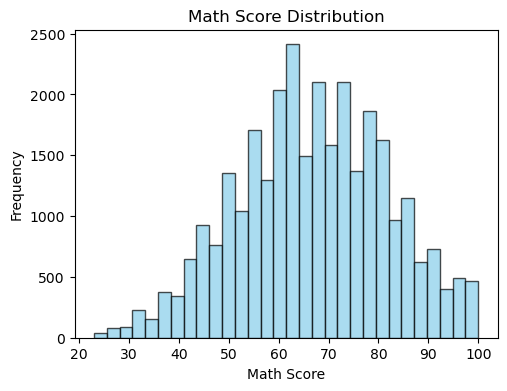

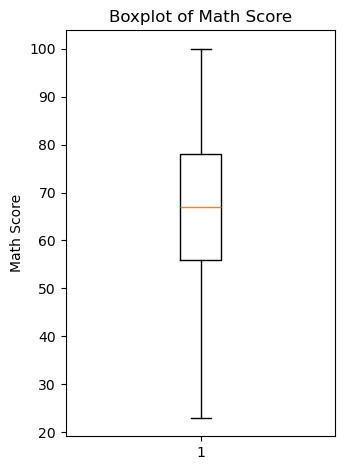

In [80]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df_clean['MathScore'], color='skyblue', bins=30, edgecolor='black', alpha=0.7)
plt.title('Math Score Distribution')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.show()

plt.subplot(1, 2, 2)
plt.boxplot(df_clean['MathScore'])
plt.title('Boxplot of Math Score')
plt.ylabel('Math Score')

plt.tight_layout()
plt.show()

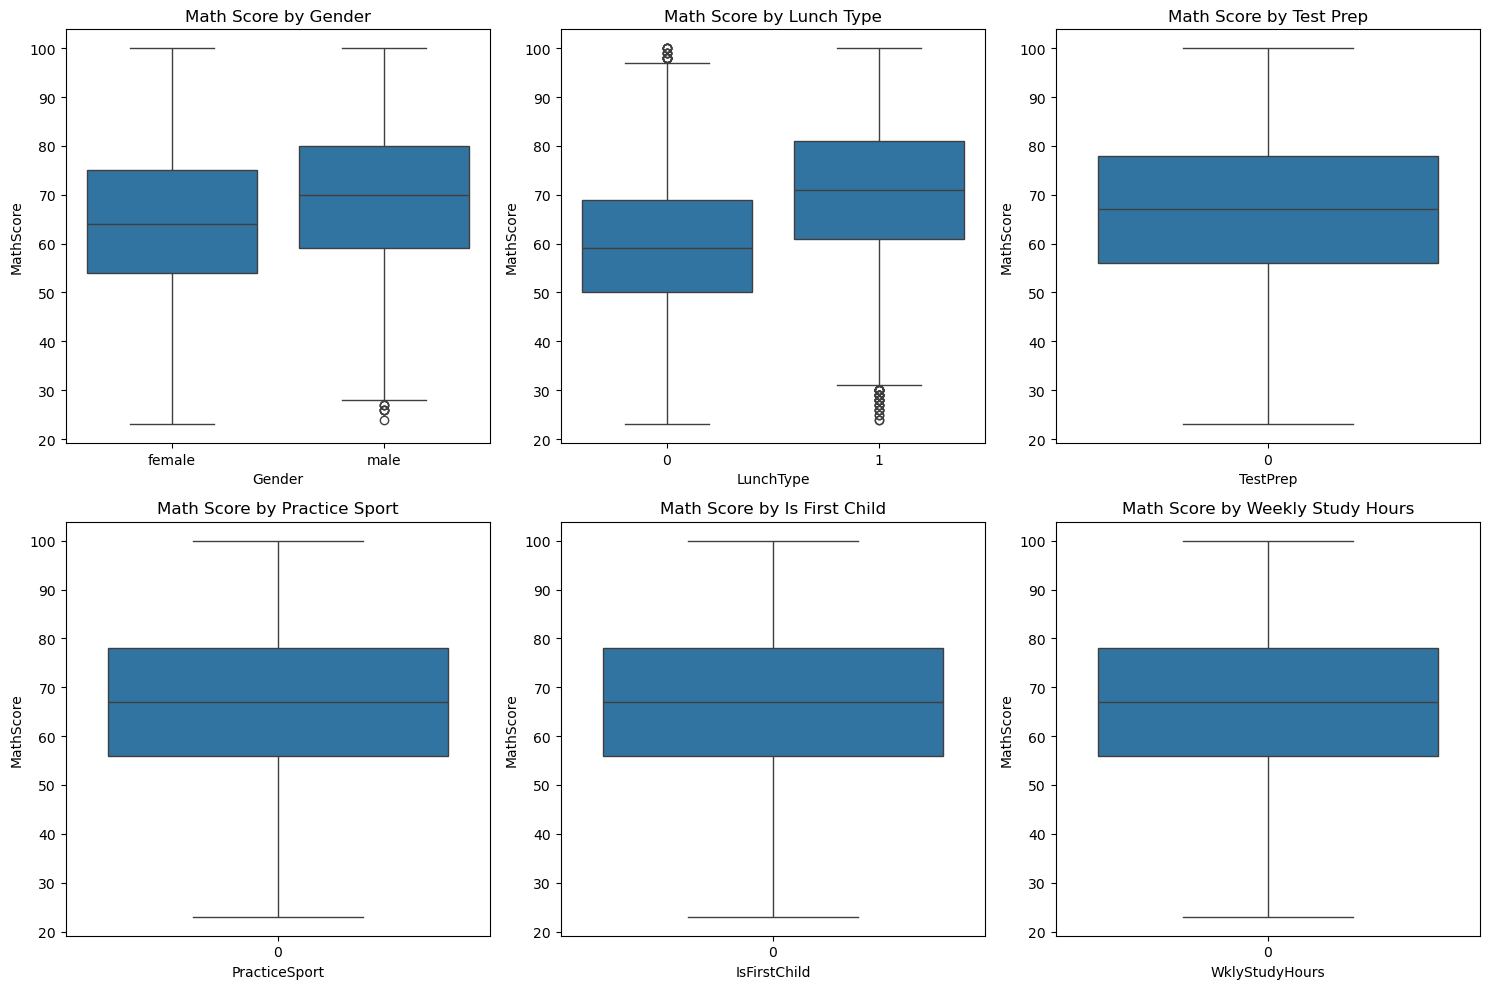

In [87]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
sns.boxplot(data=df_clean, x='Gender' , y='MathScore')
plt.title('Math Score by Gender')

plt.subplot(2,3,2)
sns.boxplot(data=df_clean, x='LunchType' , y='MathScore')
plt.title('Math Score by Lunch Type')

plt.subplot(2,3,3)
sns.boxplot(data=df_clean, x='TestPrep' , y='MathScore')
plt.title('Math Score by Test Prep')

plt.subplot(2,3,4)
sns.boxplot(data=df_clean, x='PracticeSport' , y='MathScore')
plt.title('Math Score by Practice Sport')

plt.subplot(2,3,5)
sns.boxplot(data=df_clean, x='IsFirstChild' , y='MathScore')
plt.title('Math Score by Is First Child')

plt.subplot(2,3,6)
sns.boxplot(data=df_clean, x='WklyStudyHours' , y='MathScore')
plt.title('Math Score by Weekly Study Hours')

plt.tight_layout()
plt.show()

TASK 4

In [88]:
from sklearn.preprocessing import MinMaxScaler


In [90]:
x = df_clean.drop('MathScore', axis=1)
y =df_clean['MathScore']

minmax = MinMaxScaler()

x = pd.get_dummies(x)

x_minmax = minmax.fit_transform(x)

x_minmax

array([[0.        , 0.        , 1.        , ..., 0.64383562, 1.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.83561644, 1.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.87671233, 1.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.54794521, 1.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.90410959, 1.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.42465753, 0.        ,
        1.        ]], shape=(30475, 14))

TASK 5

In [92]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_minmax, y, test_size=0.2, random_state=42) 

x_test.shape

(6095, 14)

In [93]:
x_train.shape

(24380, 14)

TASK 6

In [96]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(x_train, y_train)

y_pred= model.predict(x_test)
y_pred

array([55.09570096, 67.70105708, 74.21598993, ..., 71.91499493,
       59.27658488, 71.41744224], shape=(6095,))

TASK 7

In [99]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

r2 =r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2: {r2:.2f}')

MSE: 36.42
RMSE: 6.03
MAE: 4.81
R2: 0.84


TASK 8

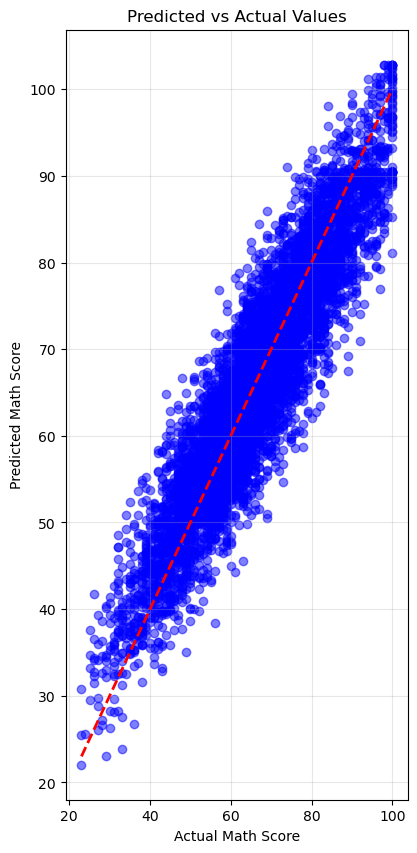

In [108]:
plt.figure(figsize=(15,10))

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.title('Predicted vs Actual Values')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Task 9 conclusion 

# I would say thre regression model works well the r^2 value is 0.84 which is 84% and RSME predicitions are off by 6 points, this model helped show how different factors from the features can affect a students preformance in maths


